In [1]:
using DifferentialEquations, LinearAlgebra, Plots

In [3]:
# Basis states
r = [0; 1]  # Assume |1>
g = [1; 0]  # Assume |0>

#Initial state
α = 1/sqrt(2)
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ρ_0 = complex(kron(ψ_a,ψ_1) * kron(ψ_a,ψ_1)');

In [4]:
struct parameters
    Ω::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V_nn::Float64     
 end

In [5]:

Δ0 = 3000
δ = -100
function (p::parameters)(t)
    global Δ0 = Δ0
    global δ =  δ
    return (Δ0+δ*t,p.Ω, p.γ_Decay, p.γ_dephase, p.V_nn)
end

p = parameters(20,0,0,-2000)

parameters(20.0, 0.0, 0.0, -2000.0)

In [6]:
p(1)

(2900, 20.0, 0.0, 0.0, -2000.0)

In [7]:
function master_eqn(dρ,ρ,p,t)

    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Δ_t, Ω, γ_Decay, γ_dephase, V_nn = p(t)
    
    #Hamiltonian
    H = Ω/2 .* kron(I,σ_x) + Δ_t .* kron(I,n) + V_nn .* kron(n,n)
    l_decay = γ_Decay .* (kron(I,σ_minus) * ρ * kron(I,σ_plus) - 0.5.*((kron(I,σ_plus) * kron(I,σ_minus) * ρ) + (ρ * kron(I,σ_plus) * kron(I,σ_minus))))
    l_dephase = γ_dephase .* (kron(I,σ_z) * ρ * kron(I,σ_z) - ρ)

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase

end

master_eqn (generic function with 1 method)

In [8]:
-2*(Δ0+p(0)[end])/δ

20.0

In [9]:
# Time span and solve the problem
tspan = (0.0,-2*(Δ0+p(0)[end])/δ)
eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
sol = solve(eqn, Rodas5(autodiff=false),saveat=0.01, progress=true);
#println(sol[end])

retcode: Success
Interpolation: 1st order linear
t: 2001-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.06
  0.07
  0.08
  0.09
  ⋮
 19.92
 19.93
 19.94
 19.95
 19.96
 19.97
 19.98
 19.99
 20.0
u: 2001-element Vector{Matrix{ComplexF64}}:
 [0.5000000000000001 + 0.0im 0.0 + 0.0im 0.5 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.5 + 0.0im 0.0 + 0.0im 0.4999999999999999 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im]
 [0.4999905383368944 + 6.2938099916126314e-18im -0.001419350323773065 - 0.0016453721405016765im 0.49990304531128915 - 0.0003550512202848493im -0.009208605212635133 - 0.0026999720895826322im; -0.0014193503237716343 + 0.0016453721405018846im 9.461663104949347e-6 - 6.294787495851145e-18im -0.0014179339634188156 + 0.0016460915458220231im 3.5021089500309164e-5 - 2.2667914303449017e-5im; 0.4999030453112894 + 0.00035505122028491726im -0.0014179339634129739 - 0.0016460915458144918im 0.49981581972621814 - 5.4569354

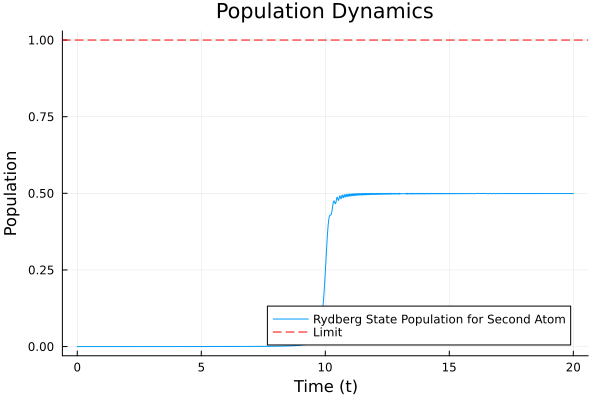

In [10]:
# Extracting populations from the solution
n = [0 0; 0 1]
I = [1 0; 0 1]

rydberg_populations = [tr(kron(I,n)*ρ) for ρ in sol.u]

# Plotting the Rydberg state population over time
plot(sol.t, real(rydberg_populations), label="Rydberg State Population for Second Atom", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")
hline!([1],color=:red,linestyle=:dash,label="Limit")

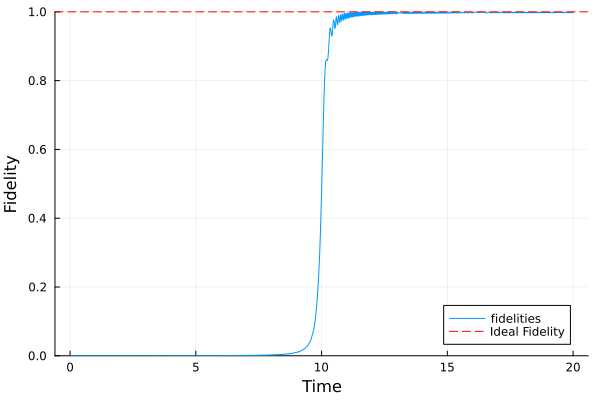

In [447]:
ψ_ideal = α*kron(r,r) + β*kron(g,g)

fidelities = []
time = []
for (t,ρ) in zip(sol.t,sol.u)
    fidelity = ψ_ideal' * ρ * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

plot(time,real(fidelities),label="fidelities",xaxis="Time",yaxis="Fidelity",ylim=(0,1))
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")

In [448]:
ΔT = []
for t in range(0,-2*(Δ0+p(0)[end])/δ)
    push!(ΔT,p(t)[1])
end
plot(time,ΔT,label="detuning",xaxis="Time",yaxis="Δ",title="Detuning")

attempt to save state beyond implementation limit
attempt to save state beyond implementation limit


## pLOTS

In [449]:
# decay = collect(range(0.0,stop=1.0,step=0.1))
# dephase = collect(range(0.0,stop=1.0,step=0.1))

# fidelity = Array{Float64}(undef, length(decay), length(dephase))
# for (i,a) in enumerate(decay)
#     for (j,b) in enumerate(dephase)

#         p = parameters(20,a,b,-2000)
#         tspan = (0.0,-2*(Δ0+p(0)[end])/δ)
#         eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
#         sol = solve(eqn, Rodas5(autodiff=false),saveat=0.01, progress=true)
        
#         ψ_ideal = α*kron(r,r) + β*kron(g,g)
#         f = tr(ψ_ideal' * sol[end] * ψ_ideal)
        
#         fidelity[i,j] = real(f) 
        
#     end
# end

In [450]:
# contourf(dephase,decay,fidelity,levels=20,color=:turbo)
# title!("F(decay,dephase)")
# xlabel!("dephase")
# ylabel!("decay")

In [451]:
# heatmap(dephase, decay, fidelity,
#         xlabel="Dephase (δ)",
#         ylabel="Decay (γ)",
#         title="Fidelity(Decay and Dephase)",
#         color=:viridis)